In [1]:
include("../RayTracing.jl")
using Plots

In [2]:
pixel = RayTracing.Pnt2(1,1)

2-element Main.RayTracing.Pnt2 with indices SOneTo(2):
 1.0
 1.0

# Independent

In [3]:
x = Float64[]
y = Float64[]
for sample_index in 1:900
    push!(x, RayTracing.rand())
    push!(y, RayTracing.rand())
end
print("ok")

ok

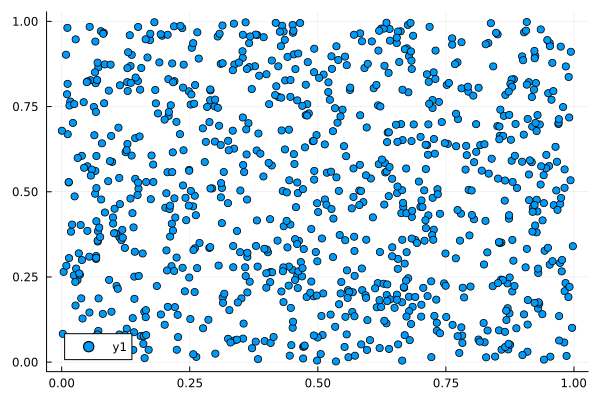

In [4]:
plot(x,y, seriestype=:scatter)

# Stratified

In [5]:
s2 = RayTracing.StratifiedSampler(900, true)

Main.RayTracing.StratifiedSampler(900, 30, 30, true, [-1.0, -1.0], 0, 0, 123456789)

In [8]:
x = Float64[]
y = Float64[]
for sample_index in 1:s2.samples_per_pixel
    RayTracing.start_pixel_sample!(s2, pixel, sample_index-1)
    camera_sample = RayTracing.get_camera_sample!(s2, pixel)
    push!(x, camera_sample.film.x-1)
    push!(y, camera_sample.film.y-1)
end
print("ok")

ok

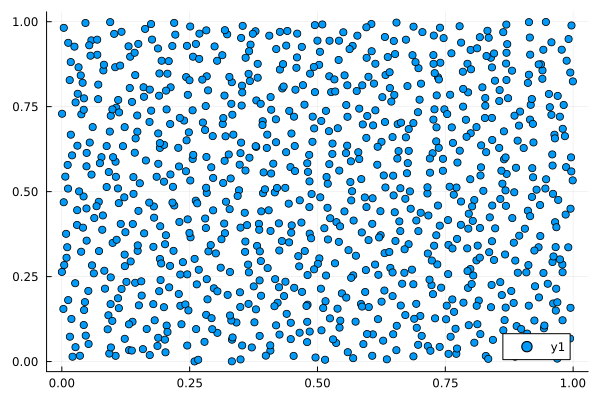

In [9]:
plot(x,y, seriestype=:scatter)

# Sobol

In [10]:
sampler = RayTracing.SobolSampler(900, RayTracing.Pnt2(250, 250), Int8(0))

Main.RayTracing.SobolSampler(900, 256, 0, 0, [0.0, 0.0], 0, 0)

In [11]:
sampler.samples_per_pixel

900

In [12]:
x = Float64[]
y = Float64[]
for sample_index in 1:sampler.samples_per_pixel
    RayTracing.start_pixel_sample!(sampler, pixel, sample_index-1)
    camera_sample = RayTracing.get_camera_sample!(sampler, pixel)
    push!(x, camera_sample.film.x)
    push!(y, camera_sample.film.y)
end
print("ok")

ok

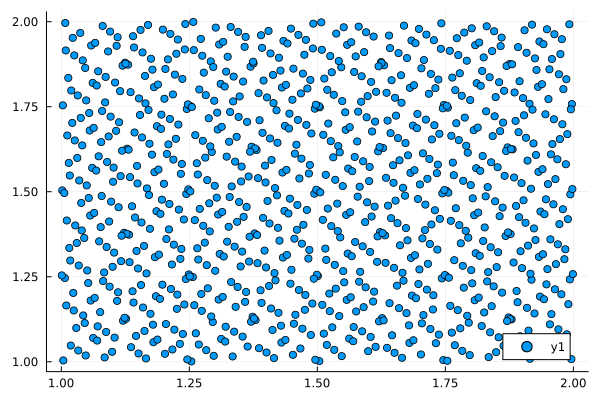

In [13]:
plot(x,y, seriestype=:scatter)